## DS2000 & DS2001 Programming with Data & Practicum

# Homework 7: Sampling, Simulations, Assessing Models, and Hypothesis Testing

### 50 Points

## Due Friday, March 14, 10:00 PM

**Reading**: 
* [Chap 9 Randomness](https://inferentialthinking.com/chapters/09/Randomness.html) 
* [Chap 10 Sampling and Empirical Distributions](https://inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html)
* [Chap 11 Testing Hypotheses](https://inferentialthinking.com/chapters/11/Testing_Hypotheses.html)

Please complete this notebook by filling in the cells provided. Before you begin, execute the following cell to load the provided tests. Each time you start your server, you will need to execute this cell again to load the tests.

For all problems that you must write our explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, please be sure to not re-assign variables throughout the notebook! For example, if you use `max_temperature` in your answer to one question, do not reassign it later on.

In [1]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

import otter
grader = otter.Notebook("hw07.ipynb")

## 1. Vaccinations Across The Nation
A vaccination clinic has two types of vaccines against a disease. Each person who comes in to be vaccinated gets either Vaccine 1 or Vaccine 2. One week, everyone who came in on Monday, Wednesday, and Friday was given Vaccine 1. Everyone who came in on Tuesday and Thursday was given Vaccine 2. The clinic is closed on weekends.

Doctor Konrad at the clinic said, "Oh wow, it's just like tossing a coin that lands heads with chance $\frac{3}{5}$. Heads you get Vaccine 1 and Tails you get Vaccine 2."

But Doctor Wang said, "No, it's not. We're not doing anything like tossing a coin."

That week, the clinic gave Vaccine 1 to 211 people and Vaccine 2 to 107 people. Conduct a test of hypotheses to see which doctor's position is better supported by the data.

**Question 1.1. (2 pts)** Given the information above, what was the sample size, and what was the percentage of people who got **Vaccine 1?** 

*Note*: Your percent should be a number between 0 and 100.

In [2]:
sample_size = 318
percent_V1 = (211/318)*100

print(f"Sample Size: {sample_size}")
print(f"Vaccine 1 Percent: {percent_V1}")

Sample Size: 318
Vaccine 1 Percent: 66.35220125786164


In [3]:
grader.check("q11")

q1_1 results: All test cases passed!

**Question 1.2. (2 pts)** State the null hypothesis. It should reflect the position of either Dr. Konrad or Dr. Wang. 

_Note_: Check out [11.3](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#step-1-the-hypotheses) for a refresher on hypotheses.

Doctor Konrad's position reflects the null hypothesis, which is that the distribution of the two vaccines resembles the chance model of tossing a coin.

**Question 1.3. (2 pts)** State the alternative hypothesis. It should reflect the position of the doctor you did not choose to represent in Question 1.2. 

_Note_: Check out [11.3](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#step-1-the-hypotheses) for a refresher on hypotheses.

Dr. Wang's position reflects the alternative hypothesis, which is that the distribution of the two vaccines does not resembele the chance model of a coin, and is in fact nothing like it.

**Question 1.4. (2 pts)** One of the test statistics below is appropriate for testing these hypotheses. Assign the variable `valid_test_stat` to the number corresponding to the correct test statistic.

_Hint:_ Recall that large values of the test statistic should favor the alternative hypothesis.

1. percent of heads - 60
2. percent of heads - 50
3. |percent of heads - 60|
4. |percent of heads - 50|


In [4]:
valid_test_stat = 3
valid_test_stat

3

In [5]:
grader.check("q14")

q1_4 results: All test cases passed!

**Question 1.5. (2 pts)** Using your answer from Questions 1.1 and 1.4, find the observed value of the test statistic and assign it to the variable `observed_statistic`. Recall that the observed statistic is the test statistic value that was observed in the real life data. 

In [6]:
observed_statistic = abs(percent_V1 - 60)
observed_statistic

6.352201257861637

In [7]:
grader.check("q15")

q1_5 results: All test cases passed!

**Question 1.6. (2 pts)** In order to perform this hypothesis test, you must simulate the test statistic. From the three options below, pick the assumption that is needed for this simulation. Assign `assumption_needed` to an integer corresponding to the assumption. 

1. The statistic must be simulated under the null hypothesis.
2. The statistic must be simulated under the alternative hypothesis.
3. The statistic must be simulated under both hypotheses.
4. No assumptions are needed. We can just simulate the statistic.

In [8]:
assumption_needed = 1
assumption_needed

1

In [9]:
grader.check("q16")

q1_6 results: All test cases passed!

**Question 1.7. (4 pts)** Simulate 20,000 values of the test statistic under the assumption you picked in Question 1.6.

As usual, start by defining a function that simulates one value of the statistic. Your function should use `sample_proportions`. (You may find a variable defined in Question 1.1 useful here!) Then write a `for` loop to simulate multiple values and collect them in the array `simulated_statistics`. 

Use as many lines of code as you need. We have included the code that visualizes the distribution of the simulated values. The red dot represents the observed statistic you found in Question 1.5.

In [10]:
def one_simulated_statistic():
   return (abs(sample_proportions(sample_size, (.60,.40)).item(0) - .60))*100
    
num_simulations = 20000

simulated_statistics = make_array()
for i in np.arange(num_simulations):
    one_sim_stat = one_simulated_statistic()
    simulated_statistics = np.append(simulated_statistics, one_sim_stat)

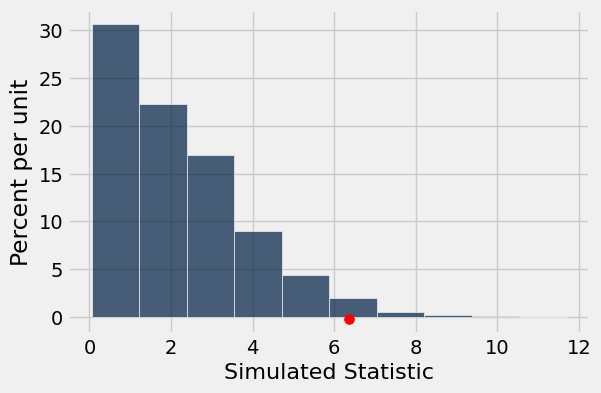

In [11]:
# Run this cell to produce a histogram of the simulated statistics

Table().with_columns('Simulated Statistic', simulated_statistics).hist()
plt.scatter(observed_statistic, -0.002, color='red', s=50);

**Question 1.8. (3 pts)** Using `simulated_statistics`, `observed_statistic`, and `num_simulations`, find the empirical p-value based on the simulation.

_Hint:_ Reading [11.3.6](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#the-meaning-of-consistent) might be helpful for this question.

In [12]:
p_value = np.count_nonzero(simulated_statistics >= observed_statistic
                          )/num_simulations
p_value

0.01705

In [13]:
grader.check("q18")

q1_8 results: All test cases passed!

**Question 1.9. (2 pts)** Assign `correct_doctor` to the number corresponding to the correct statement below. Use the 5% cutoff for the p-value. 

1. The data support Dr. Konrad's position more than they support Dr. Wang's.
2. The data support Dr. Wang's position more than they support Dr. Konrad's.

As a reminder, here are the two claims made by Dr. Konrad and Dr. Wang:
> **Doctor Konrad:** "Oh wow, it's just like tossing a coin that lands heads with chance $\frac{3}{5}$. Heads you get Vaccine 1 and Tails you get Vaccine 2."

>**Doctor Wang:** "No, it's not. We're not doing anything like tossing a coin."

In [14]:
correct_doctor = 2
correct_doctor

2

In [15]:
grader.check("q19")

q1_9 results: All test cases passed!

## 2. Assessing Jade's Models
#### Games with Jade

Our friend Jade comes over and asks us to play a game with her. The game works like this: 

> We will draw randomly with replacement from a simplified 13 card deck with 4 face cards (A, J, Q, K), and 9 numbered cards (2, 3, 4, 5, 6, 7, 8, 9, 10). If we draw cards with replacement 13 times, and if the number of face cards is greater than or equal to 4, we lose.
> 
> Otherwise, Jade wins.

We play the game once and we lose, observing 8 total face cards. We are angry and accuse Jade of cheating! Jade is adamant, however, that the deck is fair.

Jade's model claims that there is an equal chance of getting any of the cards (A, 2, 3, 4, 5, 6, 7, 8, 9, 10, J, Q, K), but we do not believe her. We believe that the deck is clearly rigged, with face cards (A, J, Q, K) being more likely than the numbered cards (2, 3, 4, 5, 6, 7, 8, 9, 10).

**Question 2.1. (2 pts)** Assign `deck_model_probabilities` to a two-item array containing the chance of drawing a face card as the first element, and the chance of drawing a numbered card as the second element under Jade's model. Since we're working with probabilities, make sure your values are between 0 and 1. 


In [16]:
deck_model_probabilities = make_array(4/13,9/13)
deck_model_probabilities

array([ 0.30769231,  0.69230769])

In [17]:
grader.check("q21")

q21 results: All test cases passed!

**Question 2.2. (2 pts)** We believe Jade's model is incorrect. In particular, we believe there to be a  larger chance of getting a face card. Which of the following statistics can we use during our simulation to test between the model and our alternative? Assign `statistic_choice` to the correct answer. 

1. The actual number of face cards we get in 13 draws
2. The distance (absolute value) between the actual number of face cards in 13 draws and the expected number of face cards in 13 draws (4)
3. The expected number of face cards in 13 draws (4)

In [18]:
statistic_choice = 1
statistic_choice

1

In [19]:
grader.check("q22")

q22 results: All test cases passed!

**Question 2.3. (3 pts)** Define the function `deck_simulation_and_statistic`, which, given a sample size and an array of model proportions (like the one you created in Question 4.1), returns the number of face cards in one simulation of drawing a card under the model specified in `model_proportions`. 

*Hint:* Think about how you can use the function `sample_proportions`. 

In [20]:
def deck_simulation_and_statistic(sample_size, model_proportions):
    return sample_proportions(sample_size, model_proportions).item(
        0) * sample_size

deck_simulation_and_statistic(13, deck_model_probabilities)

5.0

In [21]:
grader.check("q23")

q23 results: All test cases passed!

**Question 2.4. (4 pts)** Use your function from above to simulate the drawing of 13 cards 5000 times under the proportions that you specified in Question 4.1. Keep track of all of your statistics in `deck_statistics`. 

In [22]:
deck_statistics = make_array()
repetitions = 5000 

for i in np.arange(repetitions):
    deck_sim_stat = deck_simulation_and_statistic(
        13, deck_model_probabilities)
    deck_statistics = np.append(deck_statistics, deck_sim_stat)
    
deck_statistics

array([ 4.,  6.,  3., ...,  5.,  3.,  5.])

In [23]:
grader.check("q24")

q24 results: All test cases passed!

Let’s take a look at the distribution of simulated statistics.

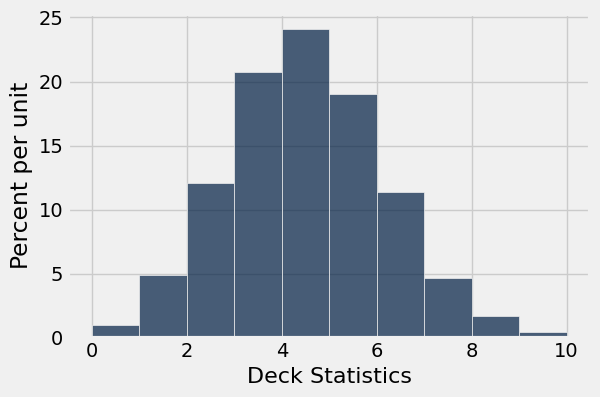

In [24]:
# Draw a distribution of statistics 
Table().with_column('Deck Statistics', deck_statistics).hist()

**Question 2.5. (3 pts)** Given your observed value, do you believe that Jade's model is reasonable, or is our alternative (that our deck is rigged) more likely? Explain your answer using the histogram produced above. 

A more likely outcome is our alternative - that the deck is rigged. The histogram shows most draws ending up with about 4 face cards, as expected. However, what is also shown is the low probability of the draw returning 8 face cards. Given these results, it seems unlikely that 8 face cards being drawn was due entirely to chance.

___

## 3. Earthquakes


The next cell loads a table containing information about **every earthquake with a magnitude above 5** in 2019 (smaller earthquakes are generally not felt, only recorded by very sensitive equipment), compiled by the US Geological Survey. (source: https://earthquake.usgs.gov/earthquakes/search/)

In [25]:
earthquakes = Table().read_table('earthquakes_2019.csv').select(['time', 'mag', 'place'])
earthquakes

time,mag,place
2019-12-31T11:22:49.734Z,5,"245km S of L'Esperance Rock, New Zealand"
2019-12-30T17:49:59.468Z,5,"37km NNW of Idgah, Pakistan"
2019-12-30T17:18:57.350Z,5.5,"34km NW of Idgah, Pakistan"
2019-12-30T13:49:45.227Z,5.4,"33km NE of Bandar 'Abbas, Iran"
2019-12-30T04:11:09.987Z,5.2,"103km NE of Chichi-shima, Japan"
2019-12-29T18:24:41.656Z,5.2,Southwest of Africa
2019-12-29T13:59:02.410Z,5.1,"138km SSW of Kokopo, Papua New Guinea"
2019-12-29T09:12:15.010Z,5.2,"79km S of Sarangani, Philippines"
2019-12-29T01:06:00.130Z,5,"9km S of Indios, Puerto Rico"
2019-12-28T22:49:15.959Z,5.2,"128km SSE of Raoul Island, New Zealand"


If we were studying all human-detectable 2019 earthquakes and had access to the above data, we’d be in good shape - however, if the USGS didn’t publish the full data, we could still learn something about earthquakes from just a smaller subsample. If we gathered our sample correctly, we could use that subsample to get an idea about the distribution of magnitudes (above 5, of course) throughout the year!

In the following lines of code, we take two different samples from the earthquake table, and calculate the **mean** of the magnitudes of these earthquakes.

In [26]:
sample1 = earthquakes.sort('mag', descending = True).take(np.arange(100))
sample1_magnitude_mean = np.mean(sample1.column('mag'))
sample2 = earthquakes.take(np.arange(100))
sample2_magnitude_mean = np.mean(sample2.column('mag'))
[sample1_magnitude_mean, sample2_magnitude_mean]

[6.4589999999999987, 5.2790000000000008]

**Question 3.1. (3 pts)**  Are these samples representative of the population of earthquakes in the original table (that is, the should we expect the mean to be close to the population mean)? 

*Hint:* Consider the ordering of the `earthquakes` table. 

No, these samples are not representative of the population of earthquakes because the first sample (sample1) takes the mean of the 100 earthquakes with the biggest magnitude in 2019. So, this mean is likely to be higher than a more correclty representative mean. The second sample (sample2) takes the mean of the first 100 earthquakes listed in the table, which would be the last 100 earthquakes of the year. While this could serve as a better representation, it is still not fully representative of the original table, as it excludes thousands of other earthquakes that occured earlier in the year, which could have had particularly high magnitudes. The earthquakes in the winter season could even reflect a different average magnitude than that of the rest of the year.

**Question 3.2. (3 pts)** Write code to produce a sample of size 200 that is representative of the population. Then, take the mean of the magnitudes of the earthquakes in this sample. Assign these to `representative_sample` and `representative_mean` respectively. 

*Hint:* In class, we learned what kind of samples should be used to properly represent the population.


In [27]:
representative_sample = earthquakes.sample(200, with_replacement=False)
representative_mean = np.average(representative_sample.column("mag"))
representative_mean

5.3266999999999998

In [28]:
grader.check("q32")

q32 results: All test cases passed!

**Question 3.3. (4 pts)** Suppose we want to figure out what the biggest magnitude earthquake was in 2019, but we only have our representative sample of 200. Let’s see if trying to find the biggest magnitude in the population from a random sample of 200 is a reasonable idea!

Write code that takes many random samples from the `earthquakes` table and finds the maximum of each sample. You should take a random sample of size 200 and do this 5000 times. Assign the array of maximum magnitudes you find to `maximums`.

In [29]:
maximums = make_array() 
num = 5000

for i in np.arange(5000):
    sim = max(earthquakes.sample(200, with_replacement=False).column("mag"))
    maximums = np.append(maximums, sim)

In [30]:
grader.check("q33")

q33 results: All test cases passed!

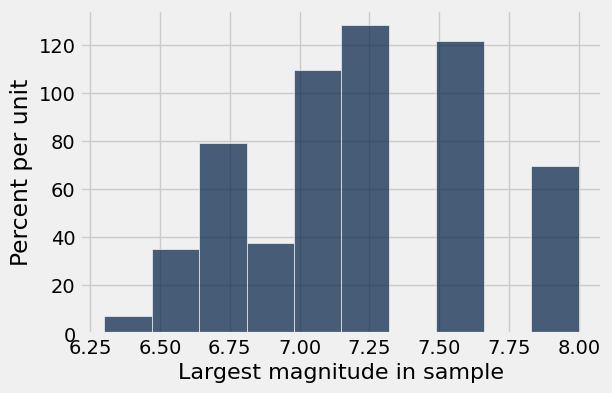

In [31]:
#Histogram of your maximums
Table().with_column('Largest magnitude in sample', maximums).hist('Largest magnitude in sample') 

**Question 3.4. (2 pts)** Now find the magnitude of the actual strongest earthquake in 2019 (not the maximum of a sample). This will help us determine whether a random sample of size 200 is likely to help you determine the largest magnitude earthquake in the population.

In [32]:
strongest_earthquake_magnitude = max(earthquakes.column("mag"))
strongest_earthquake_magnitude

8.0

In [33]:
grader.check("q34")

q34 results: All test cases passed!

**Question 3.5. (3 pts)** 
Explain whether you believe you can accurately use a sample size of 200 to determine the maximum. What is one problem with using the maximum as your estimator? Use the histogram above to help answer. 


As this histogram seems primarily Left Skewed, I would say it is somewhat accurate to determine the maximum from a sample size of 200. A fairly high number of magnitudes were 8.00, however the mode of these maximums shows a magnitude of about 7.25 occuring most often. Additionally, the lowest occurencce of maximums was closer to about 6.25. So, though many of the maximums were close to the actual maximum magnitude in 2019, there is too much variation in the data to deem it a truly accurate measurement of the maximum.
One problem with using the maximum as an estimator is that, as seen in the histogram, it is not always reflective of a majority of the magnitudes, which seem to range more commonly between 5 and 6. The lowest value in the histogram of maximum magnitudes does not even reach a magnitude of 6.

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [34]:
grader.check_all()

q1_1 results: All test cases passed!

q1_4 results: All test cases passed!

q1_5 results: All test cases passed!

q1_6 results: All test cases passed!

q1_8 results: All test cases passed!

q1_9 results: All test cases passed!

q21 results: All test cases passed!

q22 results: All test cases passed!

q23 results: All test cases passed!

q24 results: All test cases passed!

q32 results: All test cases passed!

q33 results: All test cases passed!

q34 results: All test cases passed!

**You've completed Homework 7!**

Please save your notebook, download a pdf version of the notebook, and submit it to Gradescope.